In [47]:
from cmdstanpy import CmdStanModel
import arviz as az
from sampler import CycloneDataSimulator
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches

In [62]:
def compare_posterior_draws(draws1, draws2, true_params, param_names, figsize=(14, 7), y_lim=(-8, 8), save_file=None):

    n_params = len(draws1)
    positions = np.arange(n_params)
    labels = ["Conjugate Model Draws", "Half-Cauchy Model Draws"]

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    for i, (mcmc_draw, stan_draw) in enumerate(zip(draws1, draws2)):

        if true_params is not None:
            ref_val = true_params[i]
            # offset plot slightly left/right from the reference
            vp_mcmc = ax.violinplot([mcmc_draw - ref_val], 
                                    positions=[i-0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
            vp_stan = ax.violinplot([stan_draw - ref_val], 
                                    positions=[i+0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
        else:
            vp_mcmc = ax.violinplot([mcmc_draw], 
                                    positions=[i-0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)
            vp_stan = ax.violinplot([stan_draw], 
                                    positions=[i+0.15], widths=0.25, showmeans=True, showmedians=False, showextrema=False)            
        
        # style the violin plots for each sampler
        for pc in vp_mcmc["bodies"]:
            pc.set_facecolor("#1f77b4")
            pc.set_alpha(0.5)
        vp_mcmc["cmeans"].set_color("#1f77b4")

        for pc in vp_stan["bodies"]:
            pc.set_facecolor("#ff7f0e")
            pc.set_alpha(0.5)
        vp_stan["cmeans"].set_color("#ff7f0e")

    # mark the reference values (0 because we centered the plot)
    if true_params is not None: ax.axhline(0, color="black", linewidth=1.2, linestyle="--", label="True value", zorder=5)

    # set ticks and labels
    ax.set_xticks(positions)
    ax.set_xticklabels(param_names, rotation=90)
    if true_params is not None: ax.set_ylabel("Deviation from True Value")
    else: ax.set_ylabel("Parameter Value")
    ax.set_title("Posterior Sample Comparison for Regression Parameters")

    ax.set_ylim(*y_lim)

    if true_params is not None:
        legend_handles = [
            patches.Patch(color='#1f77b4', alpha=0.7, label=labels[0]),
            patches.Patch(color='#ff7f0e', alpha=0.7, label=labels[1]),
            plt.Line2D([0], [0], color='black', linestyle='--', label='True value')
        ]
    else: 
        legend_handles = [
            patches.Patch(color='#1f77b4', alpha=0.7, label=labels[0]),
            patches.Patch(color='#ff7f0e', alpha=0.7, label=labels[1]),
        ]


    ax.legend(handles=legend_handles, loc="upper left")
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_file is not None: plt.savefig(save_file, dpi=300)
    return fig, ax

In [3]:
# load data 
data = pd.read_csv("../processed_data/processed_data.csv")
# create basin index column
data["BasinIDX"] = data[["AL", "CP", "EP"]].values.argmax(axis=1)
predictor_cols = ["ONI", "logVMAX12", "MSLP12", "POT12", "VGRAD6-12"]     # are these the right columns??
X, W = data[predictor_cols].to_numpy(), data["logVMAX36"].to_numpy()
basins = data["BasinIDX"].to_numpy()
stan_basins = basins + 1

In [7]:
# calibrated prior parameters
a = 3.
y_alpha, z_alpha = 2., 3./2.
y_gamma, z_gamma = 2., 4.
v2 = 100.
y_lam, z_lam = 2., 25.

# model parameters
B = len(set(stan_basins))               # number of ocean basins
D = X.shape[1]                          # number of predictors
N = len(W)                              # number of observations

# data for Stan
stan_data = {
    "N" : int(N), "B" : int(B), "D" : int(D),
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

Evaluate model fit of our original (mostly conjugate) model.

In [5]:
conjugate_model = CmdStanModel(stan_file = 'conjugate_model.stan')

In [8]:
conjugate_fit = conjugate_model.sample(data = stan_data, chains=4, iter_sampling=2000, iter_warmup=1000)
conjugate_draws_df = conjugate_fit.draws_pd()
conjugate_idata = az.from_cmdstanpy(posterior=conjugate_fit, log_likelihood='log_lik')

00:34:04 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]


chain 1:   3%|▎         | 100/3000 [00:00<00:03, 953.42it/s, (Warmup)]





chain 1:   7%|▋         | 200/3000 [00:08<02:23, 19.45it/s, (Warmup)] 


chain 1:  10%|█         | 300/3000 [00:14<02:29, 18.10it/s, (Warmup)]


chain 1:  13%|█▎        | 400/3000 [00:22<02:42, 15.98it/s, (Warmup)]


chain 1:  17%|█▋        | 500/3000 [00:29<02:46, 15.05it/s, (Warmup)]


chain 1:  20%|██        | 600/3000 [00:40<03:11, 12.51it/s, (Warmup)]


chain 1:  23%|██▎       | 700/3000 [00:47<03:01, 12.64it/s, (Warmup)]


chain 1:  27%|██▋       | 800/3000 [00:55<02:51, 12.82it/s, (Warmup)]


chain 1:  30%|███       | 900/3000 [01:03<02:43, 12.82it/s, (Warmup)]






chain 1:  33%|███▎      | 1000/3000 [01:14<02:55, 11.41it/s, (Sampling)]


chain 1:  37%|███▋      | 1100/3000 [01:22<02:42, 11.70it/s, (Sampling)]


chain 1:  40%|████      | 1200/3000 [01:30<02:32, 11.84it/s, (Sampling)]


c


00:38:23 - cmdstanpy - INFO - CmdStan done processing.
00:38:23 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: inv_gamma_lpdf: Scale parameter is 0, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Consider re-running with show_console=True if the above output is unclear!


00:38:24 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 1999 iterations at max treedepth (100.0%)
	Chain 2 had 1999 iterations at max treedepth (100.0%)
	Chain 3 had 1998 iterations at max treedepth (99.9%)
	Chain 4 had 1999 iterations at max treedepth (100.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [33]:
res = az.waic(conjugate_idata, scale="deviance")
conjugate_waic = res.elpd_waic
conjugate_pwaic = res.p_waic

print(f"WAIC: {conjugate_waic}")
print(f"P-WAIC: {conjugate_pwaic}")

WAIC: -258.8212041995752
P-WAIC: 16.770069519588766


/mnt/c/Users/tiara/Desktop/STAT651/cyclones/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [34]:
res = az.loo(conjugate_idata, scale="deviance")
conjugate_loo = res.elpd_loo
conjugate_ploo = res.p_loo

print(f"LOO-IC: {conjugate_loo}")
print(f"P-LOO: {conjugate_ploo}")

LOO-IC: -258.01596339230116
P-LOO: 17.17268992322579


Evaluate model fit on a model that uses Half-Cauchy instead of inverse-gamma as a prior on $\tau$.

In [42]:
# calibrated prior parameters for Cauchy
a = 3.
y_alpha, z_alpha = 2., 3./2.
y_gamma, z_gamma = 2., 4.
v2 = 100.
m = 2.5     # weakly informative

# model parameters
B = len(set(stan_basins))               # number of ocean basins
D = X.shape[1]                          # number of predictors
N = len(W)                              # number of observations

# data for Stan
cauchy_stan_data = {
    "N" : int(N), "B" : int(B), "D" : int(D),
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "m" : m,
}

In [41]:
cauchy_model = CmdStanModel(stan_file='conjugate_model-allcauchy.stan')

01:05:52 - cmdstanpy - INFO - compiling stan file /mnt/c/Users/tiara/Desktop/STAT651/cyclones/code/conjugate_model-allcauchy.stan to exe file /mnt/c/Users/tiara/Desktop/STAT651/cyclones/code/conjugate_model-allcauchy


01:06:26 - cmdstanpy - INFO - compiled model executable: /mnt/c/Users/tiara/Desktop/STAT651/cyclones/code/conjugate_model-allcauchy


In [43]:
cauchy_fit = cauchy_model.sample(data = cauchy_stan_data, chains=4, iter_sampling=2000, iter_warmup=1000)
cauchy_draws_df = cauchy_fit.draws_pd()
cauchy_idata = az.from_cmdstanpy(posterior=cauchy_fit, log_likelihood='log_lik')

01:08:17 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]


chain 1:   7%|▋         | 200/3000 [00:03<00:42, 66.66it/s, (Warmup)]


chain 1:  10%|█         | 300/3000 [00:09<01:33, 28.74it/s, (Warmup)]


chain 1:  13%|█▎        | 400/3000 [00:19<02:40, 16.22it/s, (Warmup)]


chain 1:  17%|█▋        | 500/3000 [00:27<02:45, 15.08it/s, (Warmup)]


chain 1:  20%|██        | 600/3000 [00:35<02:51, 14.03it/s, (Warmup)]


chain 1:  23%|██▎       | 700/3000 [00:43<02:49, 13.54it/s, (Warmup)]


chain 1:  27%|██▋       | 800/3000 [00:54<03:06, 11.77it/s, (Warmup)]


chain 1:  30%|███       | 900/3000 [01:02<02:53, 12.12it/s, (Warmup)]


chain 1:  33%|███▎      | 1000/3000 [01:08<02:36, 12.81it/s, (Sampling)]
























chain 1:  37%|███▋      | 1100/3000 [01:14<02:17, 13.77it/s, (Sampling)]

chain 1:  40%|████      | 1200/3000 [01:20<02:01, 14.78it/s, (Sampling)]


chain 1:  43%|████▎     | 1300/3000 [01:28<02:01, 14.02it/s, 


01:11:50 - cmdstanpy - INFO - CmdStan done processing.
01:11:50 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: inv_gamma_lpdf: Scale parameter is 0, but must be positive finite! (in 'conjugate_model-allcauchy.stan', line 50, column 4 to column 35)
	Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model-allcauchy.stan', line 52, column 8 to column 93)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model-allcauchy.stan', line 52, column 8 to column 93)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model-allcauchy.stan', line 52, column 8 to column 93)
Exception: inv_gamma_lpdf: Scale parameter is 0, but must be positive finite! (in 'conjugate_model-allcauchy.stan', line 50, column 4 t

01:11:56 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 739 divergent transitions (37.0%)
	Chain 1 had 1202 iterations at max treedepth (60.1%)
	Chain 2 had 672 divergent transitions (33.6%)
	Chain 2 had 1231 iterations at max treedepth (61.6%)
	Chain 3 had 1651 divergent transitions (82.5%)
	Chain 4 had 29 divergent transitions (1.5%)
	Chain 4 had 1970 iterations at max treedepth (98.5%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [44]:
res = az.waic(cauchy_idata, scale="deviance")
cauchy_waic = res.elpd_waic
cauchy_pwaic = res.p_waic

print(f"WAIC: {cauchy_waic}")
print(f"P-WAIC: {cauchy_pwaic}")

WAIC: -268.16529114775005
P-WAIC: 12.243714781061062


/mnt/c/Users/tiara/Desktop/STAT651/cyclones/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [45]:
res = az.loo(cauchy_idata, scale="deviance")
cauchy_loo = res.elpd_loo
cauchy_ploo = res.p_loo

print(f"LOO-IC: {cauchy_loo}")
print(f"P-LOO: {cauchy_ploo}")

/mnt/c/Users/tiara/Desktop/STAT651/cyclones/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1042: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/mnt/c/Users/tiara/Desktop/STAT651/cyclones/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


LOO-IC: -267.97922095261157
P-LOO: 12.336749878630314


Save model-fit criterion in a nice table. 

In [65]:
convergence_criterion = pd.DataFrame({
    "Model" : ["Conjugate", "Half-Cauchy"],
    "WAIC" : [conjugate_waic, cauchy_waic],
    "LOO-IC" : [conjugate_loo, cauchy_loo],
    "P_WAIC" : [conjugate_pwaic, cauchy_pwaic],
    "P_LOO" : [conjugate_ploo, cauchy_ploo],
})

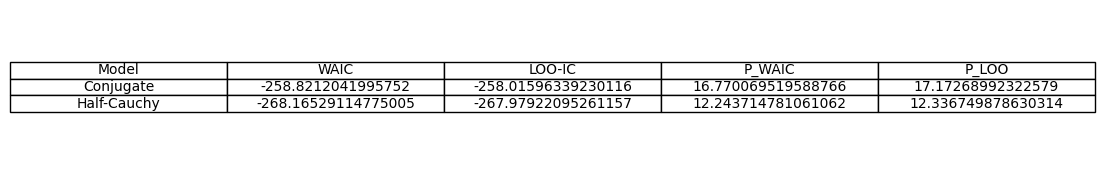

In [76]:
fig, ax = plt.subplots(figsize=(14, 2))
ax.axis("off")
ax.axis("tight")

# create table of convergence criterion
table = ax.table(
    cellText=convergence_criterion.values,
    colLabels=convergence_criterion.columns,
    cellLoc="center",
    loc="center"
)

plt.savefig("../figures/convergence_criterion.png", dpi=300)
plt.show()

In [66]:
convergence_criterion

,Model,WAIC,LOO-IC,P_WAIC,P_LOO
0,Conjugate,-258.821204,-258.015963,16.770070,17.17269
1,Half-Cauchy,-268.165291,-267.979221,12.243715,12.33675


Compare parameter estimates of the two models (for the parameters they have in common)

In [56]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]
regression_params = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)]

In [57]:
# extract stan data to an array
conjugate_draws_array = []
cauchy_draws_array = []
for param in regression_params:
    conjugate_draws_array.append(conjugate_draws_df[param])
    if "tau" in param:
        cauchy_draws_array.append(np.sqrt(cauchy_draws_df[param]))
    else:
         cauchy_draws_array.append(cauchy_draws_df[param])

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'Posterior Sample Comparison for Regression Parameters'}, ylabel='Parameter Value'>)

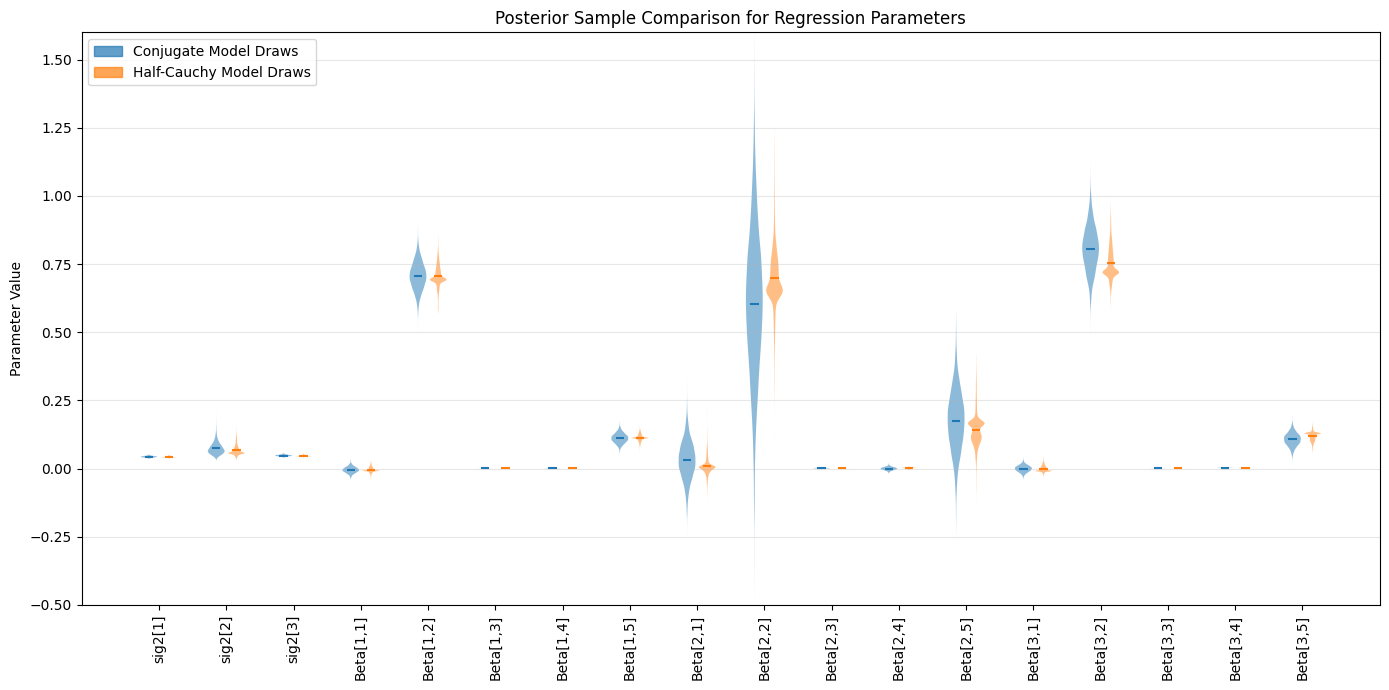

In [64]:
compare_posterior_draws(conjugate_draws_array, cauchy_draws_array, true_params=None, param_names=regression_params, y_lim=(-0.5, 1.6),
                        save_file="../figures/model_comparison.png")

Evaluate model fit on a model that uses Half-Cauchy instead of inverse-gamma as a prior on $\tau$.

In [ ]:
stan_file = 'conjugate_model-sig2cauchy.stan'
model = CmdStanModel(stan_file = stan_file)

fit = model.sample(data = stan_data, chains=4, iter_sampling=1000, iter_warmup=1000)
idata2 = az.from_cmdstanpy(posterior=fit, log_likelihood='log_lik')

In [ ]:
az.waic(idata2)

In [ ]:
az.loo(idata2)

In [ ]:
stan_file = 'conjugate_model-allcauchy.stan'
model = CmdStanModel(stan_file = stan_file)

fit = model.sample(data = stan_data, chains=4, iter_sampling=1000, iter_warmup=1000)
idata3 = az.from_cmdstanpy(posterior=fit, log_likelihood='log_lik')

In [ ]:
az.waic(idata3)

In [ ]:
az.loo(idata3)